In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, boxcox
from sklearn.preprocessing import MinMaxScaler

In [167]:
data = {
    'Student_ID': [1,2,3,4,5,6,7,8,9,10],
    'Name': ['Ram', 'Mohan', 'Sohan', 'Rahul', 'Geeta', 'John', 'Charlie', 'Sahil', 'Anil', 'Ravi'],
    'Age': [20, 21, 19, 22, 20, 21, 19, 22, 20, 21],
    'Math_Score': [8, 29, 85, np.nan, 78, 95, 89, 34, 82, 250],
    'Science_Score': [92, 88, 84, 87, 91, np.nan, 85, 89, 10, 88],
    'English_Score': [85, 90, 88, 36, 84, 89, 91, 87, 85, 10],
    'Attendance_Percentage': [95, 96, 93, 37, 29, 91, 90, 89, 88, 200],
    'feedback': ['good', 'average', 'excellent', 'average', 'good', 'excellent', 'excellent', 'good', 'average', 'good']
}

In [168]:
df = pd.DataFrame(data)

In [169]:
df.columns

Index(['Student_ID', 'Name', 'Age', 'Math_Score', 'Science_Score',
       'English_Score', 'Attendance_Percentage', 'feedback'],
      dtype='object')

In [170]:
df.dtypes

Student_ID                 int64
Name                      object
Age                        int64
Math_Score               float64
Science_Score            float64
English_Score              int64
Attendance_Percentage      int64
feedback                  object
dtype: object

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10 non-null     int64  
 1   Name                   10 non-null     object 
 2   Age                    10 non-null     int64  
 3   Math_Score             9 non-null      float64
 4   Science_Score          9 non-null      float64
 5   English_Score          10 non-null     int64  
 6   Attendance_Percentage  10 non-null     int64  
 7   feedback               10 non-null     object 
dtypes: float64(2), int64(4), object(2)
memory usage: 772.0+ bytes


In [172]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Student_ID               0
Name                     0
Age                      0
Math_Score               1
Science_Score            1
English_Score            0
Attendance_Percentage    0
feedback                 0
dtype: int64


In [173]:
df.describe()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Attendance_Percentage
count,10.00000,10.000000,9.000000,9.000000,10.000000,10.00000
mean,5.50000,20.500000,83.333333,79.333333,74.500000,90.80000
std,3.02765,1.080123,69.856997,26.124701,27.917537,45.58216
min,1.00000,19.000000,8.000000,10.000000,10.000000,29.00000
25%,3.25000,20.000000,34.000000,85.000000,84.250000,88.25000
50%,5.50000,20.500000,82.000000,88.000000,86.000000,90.50000
75%,7.75000,21.000000,89.000000,89.000000,88.750000,94.50000
max,10.00000,22.000000,250.000000,92.000000,91.000000,200.00000


In [174]:
df = df.fillna(df.mean(numeric_only = True))

In [175]:
df.isnull().sum()

Student_ID               0
Name                     0
Age                      0
Math_Score               0
Science_Score            0
English_Score            0
Attendance_Percentage    0
feedback                 0
dtype: int64

In [176]:
numeric_cols = ['Age', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance_Percentage']

In [177]:
print("\n=== Outlier Detection using IQR Method ===")
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1


=== Outlier Detection using IQR Method ===


In [178]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [179]:
outliers = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))
outlier_rows = outliers.any(axis=1)
print("\nLower Bound (Q1 - 1.5*IQR):\n", lower_bound)
print("\nUpper Bound (Q3 + 1.5*IQR):\n", upper_bound)
print("\nOutliers Found:\n", df[outlier_rows])


Lower Bound (Q1 - 1.5*IQR):
 Age                      18.500
Math_Score              -19.500
Science_Score            77.500
English_Score            77.500
Attendance_Percentage    78.875
dtype: float64

Upper Bound (Q3 + 1.5*IQR):
 Age                       22.500
Math_Score               152.500
Science_Score             95.500
English_Score             95.500
Attendance_Percentage    103.875
dtype: float64

Outliers Found:
    Student_ID   Name  Age  Math_Score  Science_Score  English_Score  \
3           4  Rahul   22   83.333333           87.0             36   
4           5  Geeta   20   78.000000           91.0             84   
8           9   Anil   20   82.000000           10.0             85   
9          10   Ravi   21  250.000000           88.0             10   

   Attendance_Percentage feedback  
3                     37  average  
4                     29     good  
8                     88  average  
9                    200     good  


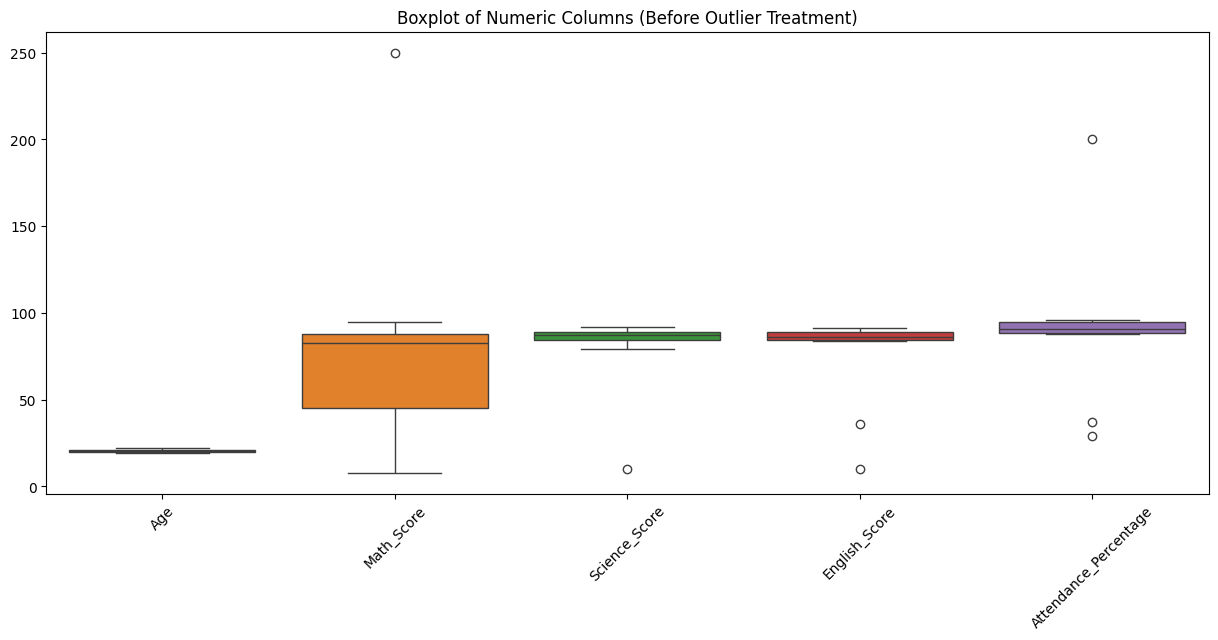

In [180]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Columns (Before Outlier Treatment)")
plt.xticks(rotation=45)
plt.show()

In [181]:
# Cap outliers (Winsorization)
for col in numeric_cols:
    df[col] = np.where(df[col] > upper_bound[col], upper_bound[col], df[col])
    df[col] = np.where(df[col] < lower_bound[col], lower_bound[col], df[col])


=== After Outlier Treatment ===


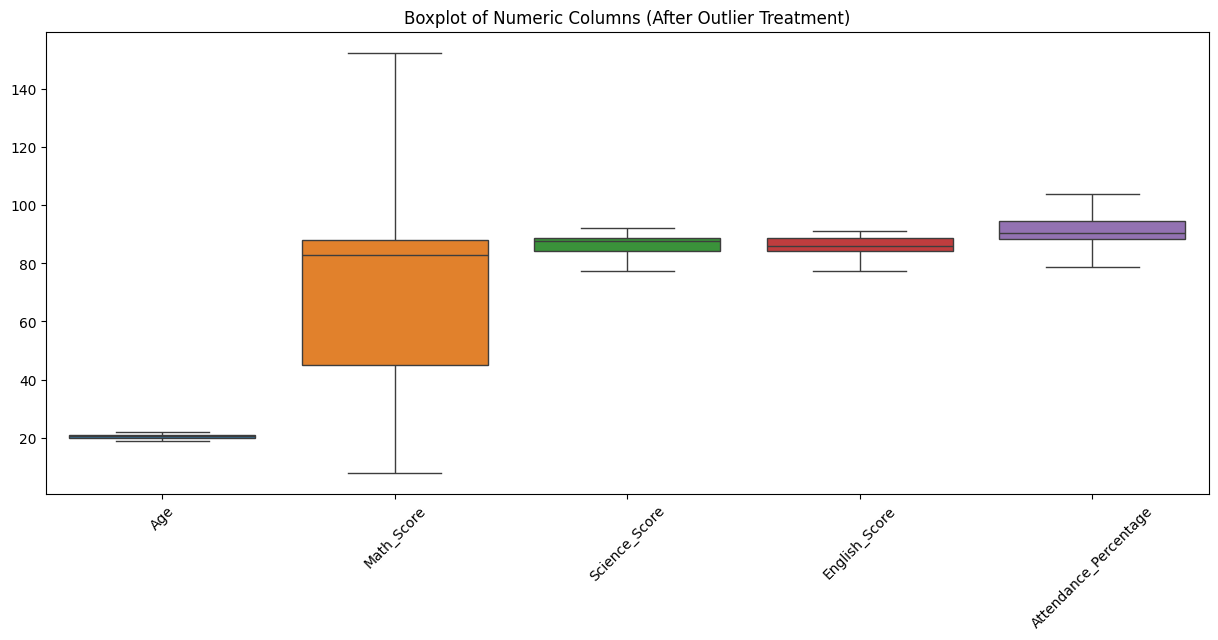

In [182]:
print("\n=== After Outlier Treatment ===")
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Columns (After Outlier Treatment)")
plt.xticks(rotation=45)
plt.show()

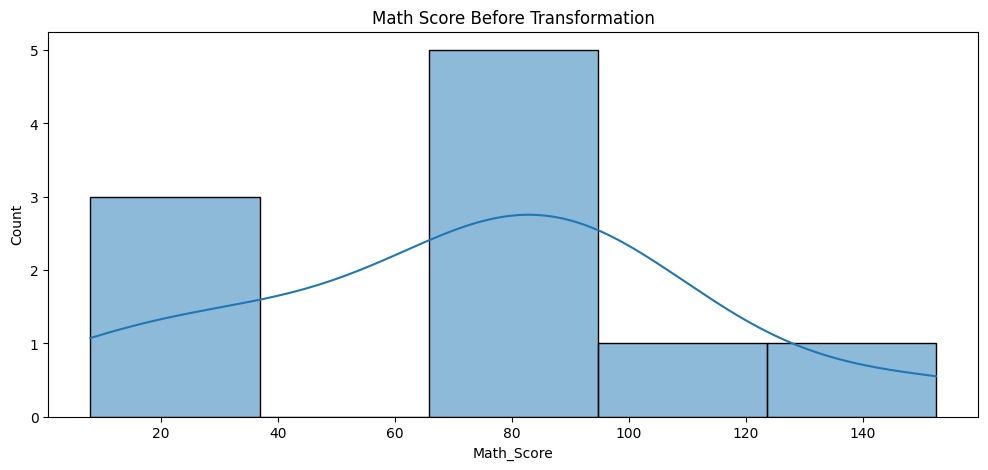

In [183]:
plt.figure(figsize=(12,5))
sns.histplot(df['Math_Score'], kde=True)
plt.title("Math Score Before Transformation")
plt.show()

In [184]:
before_skew = df['Math_Score'].skew()
print(f"Skewness of Math_Score before transformation: {before_skew:.4f}")

Skewness of Math_Score before transformation: 0.1523


In [185]:
df['Math_Score_Transformed'], _ = boxcox(df['Math_Score'])

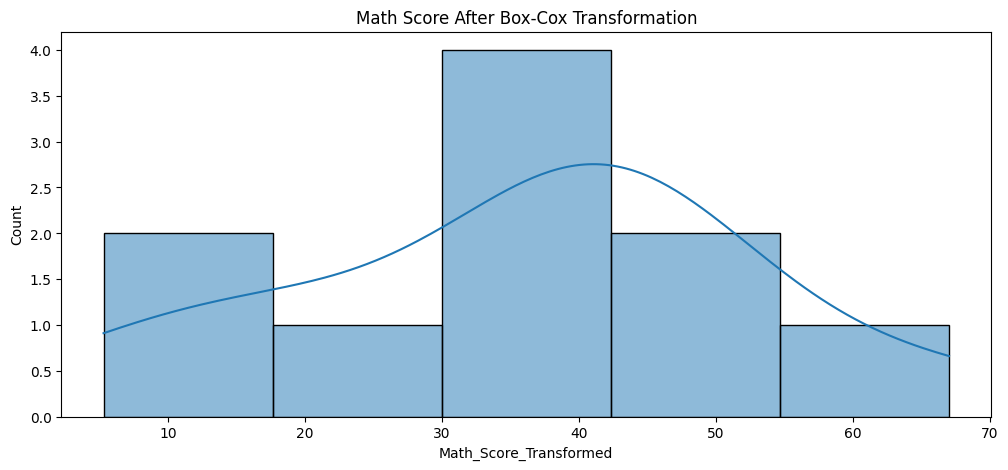

In [186]:
plt.figure(figsize=(12,5))
sns.histplot(df['Math_Score_Transformed'], kde=True)
plt.title("Math Score After Box-Cox Transformation")
plt.show()

In [187]:
after_skew = pd.Series(df['Math_Score_Transformed']).skew()
print(f"Skewness of Math_Score after transformation: {after_skew:.4f}")

Skewness of Math_Score after transformation: -0.2166


In [188]:
print("\nCleaned Dataset:\n")
print(df.head())


Cleaned Dataset:

   Student_ID   Name   Age  Math_Score  Science_Score  English_Score  \
0           1    Ram  20.0    8.000000           92.0           85.0   
1           2  Mohan  21.0   29.000000           88.0           90.0   
2           3  Sohan  19.0   85.000000           84.0           88.0   
3           4  Rahul  22.0   83.333333           87.0           77.5   
4           5  Geeta  20.0   78.000000           91.0           84.0   

   Attendance_Percentage   feedback  Math_Score_Transformed  
0                 95.000       good                5.308564  
1                 96.000    average               17.010564  
2                 93.000  excellent               41.669221  
3                 78.875    average               40.999167  
4                 78.875       good               38.836100  


In [189]:
print(df['feedback'].nunique())
print(df['feedback'].unique())

3
['good' 'average' 'excellent']


In [190]:
def encode_feedback(val):
    if val == 'excellent':
        return 3
    if val == 'good':
        return 2
    if val == 'average':
        return 1

In [191]:
df['feedback'] = df['feedback'].apply(encode_feedback)

In [192]:
df.head()

,Student_ID,Name,Age,Math_Score,Science_Score,English_Score,Attendance_Percentage,feedback,Math_Score_Transformed
0,1,Ram,20.0,8.000000,92.0,85.0,95.000,2,5.308564
1,2,Mohan,21.0,29.000000,88.0,90.0,96.000,1,17.010564
2,3,Sohan,19.0,85.000000,84.0,88.0,93.000,3,41.669221
3,4,Rahul,22.0,83.333333,87.0,77.5,78.875,1,40.999167
4,5,Geeta,20.0,78.000000,91.0,84.0,78.875,2,38.836100
